In [2]:
# Built-in
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout
)
from keras_cv_attention_models import mobilevit
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


In [3]:
# Define the path to the dataset
base_path = '/kaggle/input/datasets/haidang2519/deepmfake/ff23/ff23'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)

In [4]:
# Đảm bảo đã có df_cropped.csv chứa đường dẫn ảnh đã crop
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})
df


,filename,path,id,frame,label,label_id
0,107_109_frame_0013.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,107,13,fake,0
1,793_768_frame_0018.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,793,18,fake,0
2,377_333_frame_0022.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,377,22,fake,0
3,325_492_frame_0000.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,325,0,fake,0
4,663_231_frame_0003.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,663,3,fake,0
...,...,...,...,...,...,...
59803,325_frame_0025.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,325,25,real,1
59804,328_frame_0015.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,328,15,real,1
59805,035_frame_0004.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,35,4,real,1
59806,618_frame_0028.jpg,/kaggle/input/datasets/haidang2519/deepmfake/f...,618,28,real,1


In [5]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [6]:
# Chuẩn bị dữ liệu
video_keys = list(video_dict.keys())
video_labels = [labels[k] for k in video_keys]

# Cấu hình
img_size = (224, 224)
batch_size = 32
epochs = 50
n_splits = 5
sequence_len = 10
results = []
all_histories = []

# Custom data generator để nạp chuỗi ảnh từ video_dict
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels, batch_size, img_size, sequence_len=10, augment=False):
        self.video_keys = video_keys
        self.video_dict = video_dict
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_len = sequence_len
        self.augment = augment
        self.datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15 if augment else 0,
            zoom_range=0.1 if augment else 0,
            horizontal_flip=augment
        )

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def __getitem__(self, idx):
        batch_keys = self.video_keys[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X, batch_y = [], []

        for key in batch_keys:
            frames = video_dict[key][:self.sequence_len]
            imgs = []
            for path in frames:
                img = cv2.imread(path)
                img = cv2.resize(img, self.img_size)
                img = self.datagen.random_transform(img) if self.augment else img
                img = img.astype('float32') / 255.0
                imgs.append(img)
            while len(imgs) < self.sequence_len:
                imgs.append(np.zeros((*self.img_size, 3), dtype='float32'))  # padding
            batch_X.append(imgs)
            batch_y.append(self.labels[key])

        return np.array(batch_X), np.array(batch_y)

# Hàm xây dựng mô hình
def build_model(sequence_len, img_size):
    base_model = mobilevit.MobileViT_V2_050(input_shape=(*img_size, 3), pretrained="imagenet", num_classes=0)

    # Freeze toàn bộ backbone để giảm overfit
    base_model.trainable = False

    # CNN feature extractor
    model_out = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=model_out)

    # Sequence input
    input_seq = Input(shape=(sequence_len, *img_size, 3))
    x = TimeDistributed(model)(input_seq)

    # LSTM đơn giản hơn
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Không dùng nhiều Dense, chỉ một đầu ra
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_seq, outputs=output)
    return model

# K-Fold huấn luyện
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, video_labels), 1):
    print(f"\n===== Fold {fold} =====")

    trainval_keys = [video_keys[i] for i in trainval_idx]
    test_keys = [video_keys[i] for i in test_idx]

    y_trainval = [labels[k] for k in trainval_keys]
    train_keys, val_keys = train_test_split(trainval_keys, test_size=0.1, stratify=y_trainval, random_state=fold)

    train_gen = VideoSequence(train_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=True)
    val_gen   = VideoSequence(val_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)
    test_gen  = VideoSequence(test_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)

    model = build_model(sequence_len, img_size)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

    model_path = f"best_model_fold{fold}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

    history = model.fit(train_gen, validation_data=val_gen,
                        epochs=epochs, callbacks=[checkpoint, earlystop, reduce_lr], verbose=1)

    all_histories.append(history.history)

    model.load_weights(model_path)

    y_true = [labels[k] for k in test_keys]
    y_pred_prob = model.predict(test_gen).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_pred_prob)
    })

# Tổng kết kết quả
print("\n📊 Tổng kết kết quả các fold:")
for r in results:
    print(f"Fold {r['fold']}: Accuracy={r['accuracy']:.4f}, F1={r['f1']:.4f}, AUC={r['auc']:.4f}")



===== Fold 1 =====


I0000 00:00:1774954328.469486      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


6124776/6124776 [==============================] - 0s 0us/step
>>>> Load pretrained from: /root/.keras/models/mobilevit_v2_050_256_imagenet.h5
Epoch 1/50


I0000 00:00:1774954363.619790      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774954368.322820      74 service.cc:152] XLA service 0x7824b0518be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774954368.322858      74 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774954368.571513      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 [==============================] - ETA: 0s - loss: 0.7094 - accuracy: 0.4944
Epoch 1: val_accuracy improved from -inf to 0.51250, saving model to best_model_fold1.h5


...

45/45 [==============================] - 191s 4s/step - loss: 0.7065 - accuracy: 0.4958 - val_loss: 0.6950 - val_accuracy: 0.5063 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6862 - accuracy: 0.5410
Epoch 2: val_accuracy improved from 0.50625 to 0.53125, saving model to best_model_fold3.h5
45/45 [==============================] - 169s 4s/step - loss: 0.6862 - accuracy: 0.5410 - val_loss: 0.6868 - val_accuracy: 0.5312 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6892 - accuracy: 0.5396
Epoch 3: val_accuracy improved from 0.53125 to 0.55000, saving model to best_model_fold3.h5
45/45 [==============================] - 170s 4s/step - loss: 0.6892 - accuracy: 0.5396 - val_loss: 0.6795 - val_accuracy: 0.5500 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6791 - accuracy: 0.5708
Epoch 4: val_accuracy improved from 0.55000 to 0.60625, saving model to best_model_fold3.h5
4

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 198s 4s/step - loss: 0.6987 - accuracy: 0.5104 - val_loss: 0.6884 - val_accuracy: 0.5250 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6896 - accuracy: 0.5299
Epoch 2: val_accuracy improved from 0.52500 to 0.56250, saving model to best_model_fold4.h5
45/45 [==============================] - 175s 4s/step - loss: 0.6896 - accuracy: 0.5299 - val_loss: 0.6806 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6784 - accuracy: 0.5868
Epoch 3: val_accuracy improved from 0.56250 to 0.62500, saving model to best_model_fold4.h5
45/45 [==============================] - 183s 4s/step - loss: 0.6784 - accuracy: 0.5868 - val_loss: 0.6714 - val_accuracy: 0.6250 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6705 - accuracy: 0.5938
Epoch 4: val_accuracy did not improve from 0.62500
45/45 [==============================] - 1

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 191s 4s/step - loss: 0.6957 - accuracy: 0.5396 - val_loss: 0.6862 - val_accuracy: 0.5437 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6859 - accuracy: 0.5451
Epoch 2: val_accuracy improved from 0.54375 to 0.60000, saving model to best_model_fold5.h5
45/45 [==============================] - 169s 4s/step - loss: 0.6859 - accuracy: 0.5451 - val_loss: 0.6816 - val_accuracy: 0.6000 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6803 - accuracy: 0.5750
Epoch 3: val_accuracy improved from 0.60000 to 0.60625, saving model to best_model_fold5.h5
45/45 [==============================] - 171s 4s/step - loss: 0.6803 - accuracy: 0.5750 - val_loss: 0.6767 - val_accuracy: 0.6062 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6743 - accuracy: 0.5778
Epoch 4: val_accuracy did not improve from 0.60625
45/45 [==============================] - 1

In [7]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.689500
precision    0.671759
recall       0.762000
f1           0.711292
auc          0.757715
dtype: float64


,fold,accuracy,precision,recall,f1,auc
0,1,0.7000,0.683486,0.745,0.712919,0.756025
1,2,0.6175,0.590734,0.765,0.666667,0.662650
2,3,0.7625,0.766497,0.755,0.760705,0.801775
3,4,0.6850,0.681373,0.695,0.688119,0.772050
4,5,0.6825,0.636704,0.850,0.728051,0.796075


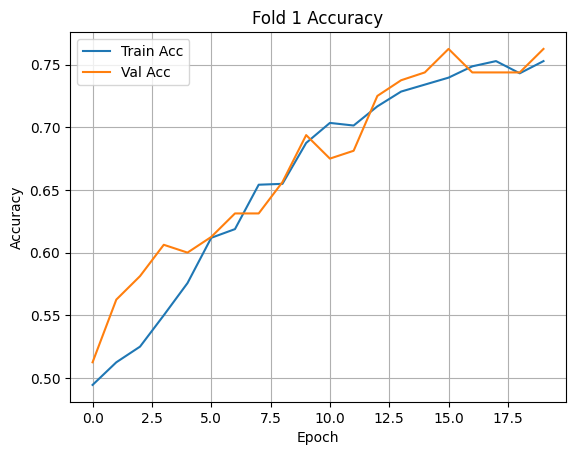

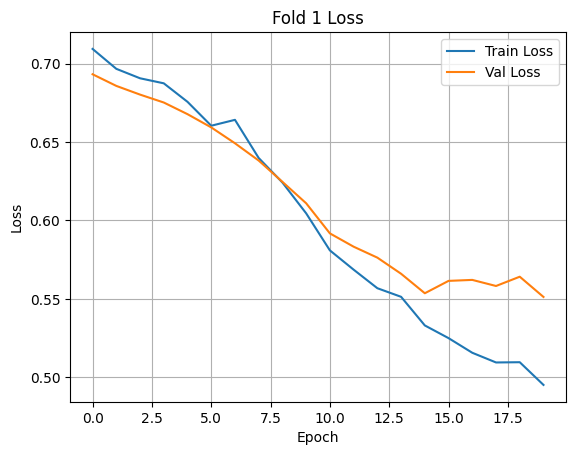

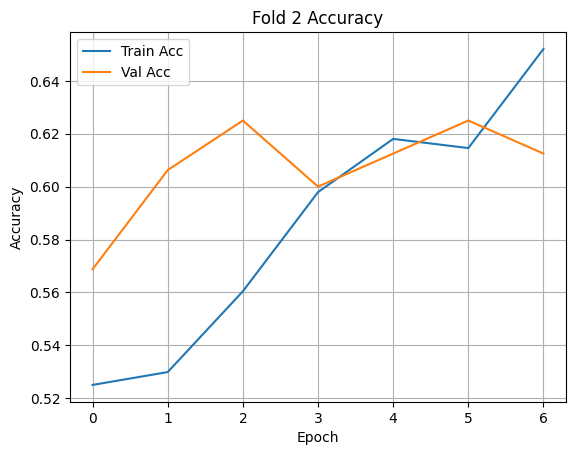

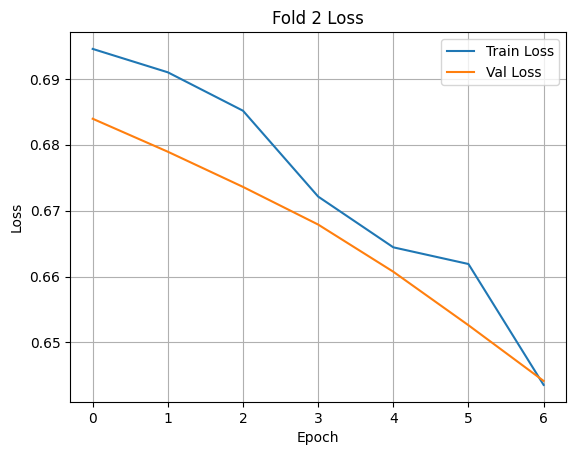

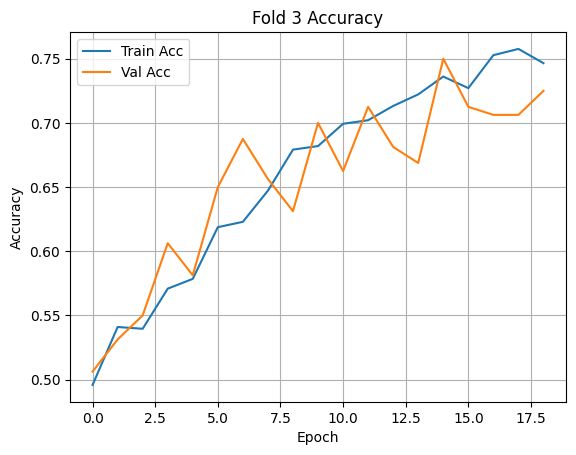

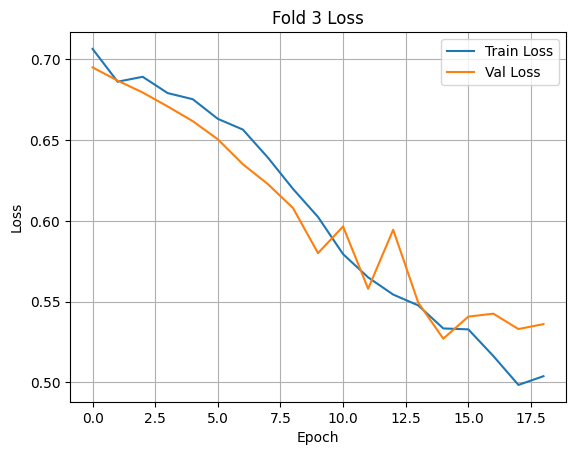

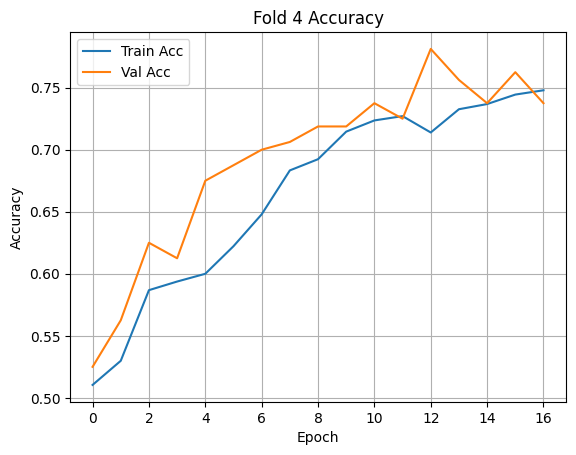

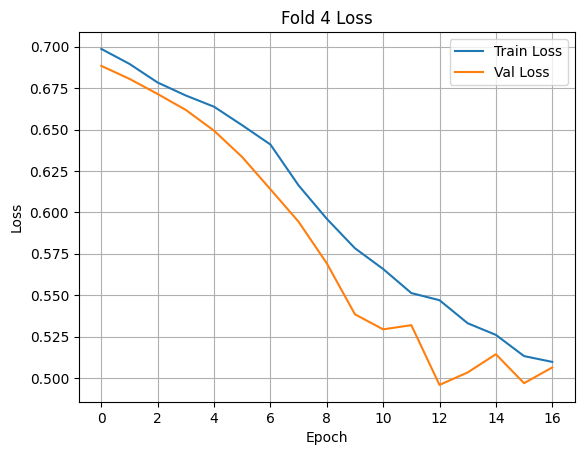

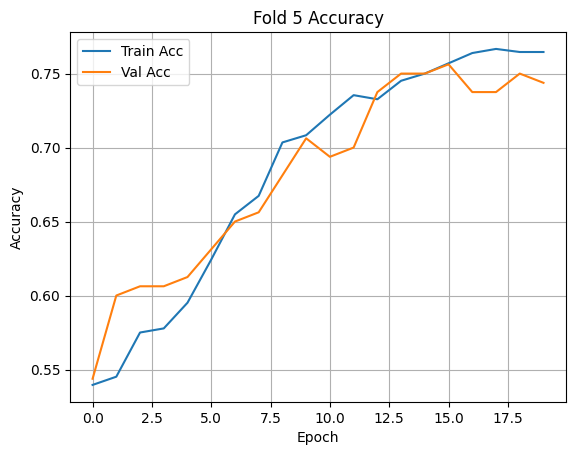

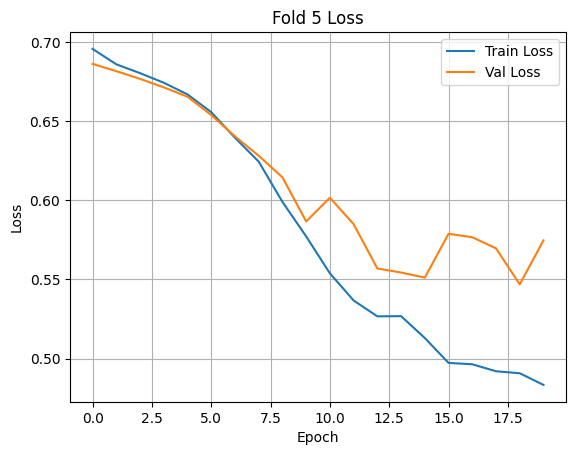

In [8]:
for i, hist in enumerate(all_histories, 1):
    plt.figure()
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


### 